In [1]:
import numpy as np
import networkx as nx
import time
from matplotlib.lines import Line2D
import pandas as pd

# !pip install tikzplotlib
# ============================================================
# Export current Matplotlib figure to PNG and TikZ
# with tikzplotlib/webcolors compatibility fix
# ============================================================

import matplotlib.pyplot as plt
import webcolors

# ------------------------------------------------------------
# Fix compatibility between tikzplotlib and newer webcolors
# ------------------------------------------------------------
#webcolors.CSS3_HEX_TO_NAMES = {
#    webcolors.name_to_hex(name): name
#    for name in webcolors.names("css3")
#}


# ------------------------------------------------------------
# Import tikzplotlib AFTER applying the compatibility fix
# ------------------------------------------------------------
import tikzplotlib

In [2]:
def MAT_AND(A, B):
    """
    Matrix AND operation:
        A AND B = A * pinv(A+B) * B
    """
    P = np.linalg.pinv(A + B)
    return A @ P @ B

In [3]:
def MAT_OR(A, B):
    """
    Matrix OR operation.
    """
    return A + B

In [4]:
def MAT_Decision(A, n, d, tol=1e-7):
    """
    Apply the matrix decision operation block by block.

    Parameters
    ----------
    A : ndarray
        (dn) x (dn) matrix
    n : int
        Number of agents/vertices
    d : int
        Dimension of each matrix weight
    tol : float
        Numerical tolerance
    """
    D = np.zeros((d * n, d * n))

    for i in range(n):
        for j in range(n):

            # Extract d x d block A_ij
            Aij = A[i*d:(i+1)*d, j*d:(j+1)*d]

            # If Aij is approximately zero
            if np.sum(np.abs(Aij)) < tol:
                D[i*d:(i+1)*d, j*d:(j+1)*d] = np.zeros((d, d))

            else:
                # Since your matrix weights are presumably symmetric,
                # eigvalsh is preferable to eig.
                eigenvalues = np.linalg.eigvalsh(Aij)

                if np.all(eigenvalues > tol):
                    D[i*d:(i+1)*d, j*d:(j+1)*d] = np.eye(d)
                else:
                    D[i*d:(i+1)*d, j*d:(j+1)*d] = Aij

    return D

In [5]:
def MATprod(A, B, n, d):
    """
    Matrix product for matrix-weighted matrices.

    C_ij = OR_k [ AND(A_ik, B_kj) ]
    """
    C = np.zeros((d * n, d * n))

    for i in range(n):
        for j in range(n):

            Cij = np.zeros((d, d))

            for kk in range(n):

                # Extract blocks
                Aik = A[i*d:(i+1)*d, kk*d:(kk+1)*d]
                Bkj = B[kk*d:(kk+1)*d, j*d:(j+1)*d]

                # Cij = Cij OR (Aik AND Bkj)
                Cij = MAT_OR(Cij, MAT_AND(Aik, Bkj))

            # Put Cij into C
            C[i*d:(i+1)*d, j*d:(j+1)*d] = Cij

    return C

In [6]:
def MATpow(A, power, n, d):
    """
    Matrix power under the matrix-weighted product.

    MATLAB:
        P = eye(d*n)
        for i = 1:k
            P = (MATprod(P,A,n,d) + MATprod(A,P,n,d))/2;
        end
    """
    if power <= 0:
        return np.eye(d * n)

    P = np.eye(d * n)

    for _ in range(power):
        P = (
            MATprod(P, A, n, d)
            + MATprod(A, P, n, d)
        ) / 2.0

    return P


In [7]:
def Warshall(A, n, d, tol=1e-6):
    """
    Generalized Warshall algorithm for matrix-weighted graphs.

    Parameters
    ----------
    A : ndarray
        dn x dn matrix-weighted adjacency matrix
    n : int
        Number of vertices/agents
    d : int
        Dimension of each matrix weight
    tol : float
        Tolerance for convergence

    Returns
    -------
    C : ndarray
        Final connectivity/decision matrix
    k : int
        Number of iterations required.
        Returns -1 if convergence is not detected.
    """

    # C = eye(d*n)
    C = np.eye(d * n)
    C_old = np.eye(d * n)
    
    # k = -1
    k = -1
    check = 0
    # B = kron(ones(n,n),eye(d))
    B = np.kron(np.ones((n, n)), np.eye(d))

    for i in range(1, n):
        C_old = C
        
        C = MAT_Decision(
            MAT_OR(C, MATpow(A, i, n, d)),
            n,
            d
        )
        
        for p in range(1,n):
            for q in range(p+1,n):
                if not (np.linalg.matrix_rank(C[p*d:(p+1)*d, q*d:(q+1)*d])==np.linalg.matrix_rank(C_old[p*d:(p+1)*d, q*d:(q+1)*d])
                     and np.linalg.matrix_rank(C[p*d:(p+1)*d, q*d:(q+1)*d])==np.linalg.matrix_rank(C[p*d:(p+1)*d, q*d:(q+1)*d]+C_old[p*d:(p+1)*d, q*d:(q+1)*d])):
                    check = 1
                    break
                
        # MATLAB:
        # if sum(abs(C-B),'all') < 0.000001
        if ((np.sum(np.abs(C - B)) < tol) or (check==0)):
            k = i
            break

    # Final decision operation
    C = MAT_Decision(C, n, d)

    return C, k

In [16]:
def Warshall_ET(A, n, d, ET, tol=1e-6):
    """
    Generalized Warshall algorithm for matrix-weighted graphs with early terminated time.

    Parameters
    ----------
    A : ndarray
        dn x dn matrix-weighted adjacency matrix
    n : int
        Number of vertices/agents
    d : int
        Dimension of each matrix weight
    tol : float
        Tolerance for convergence

    Returns
    -------
    C : ndarray
        Final connectivity/decision matrix
    k : int
        Number of iterations required.
        Returns -1 if convergence is not detected.
    """

    # C = eye(d*n)
    C = np.eye(d * n)
    C_old = np.eye(d * n)
    
    # k = -1
    k = -1
    # check = 0
    # B = kron(ones(n,n),eye(d))
    B = np.kron(np.ones((n, n)), np.eye(d))

    for i in range(1, n):
        C_old = C
        
        C = MAT_Decision(
            MAT_OR(C, MATpow(A, i, n, d)),
            n,
            d
        )
        
        if ((np.sum(np.abs(C - B)) < tol) or (i==ET)):
            k = i
            break

    # Final decision operation
    C = MAT_Decision(C, n, d)

    return C, k

Number of vertices: 100
Number of edges: 434

Total edges: 434
PD edges: 87
PSD edges: 347
PD percentage: 20.046082949308754 %
PSD percentage: 79.95391705069125 %

A shape: (200, 200)

Verified PD weights: 87
Verified PSD weights: 347

Number of different matrix weights: 4


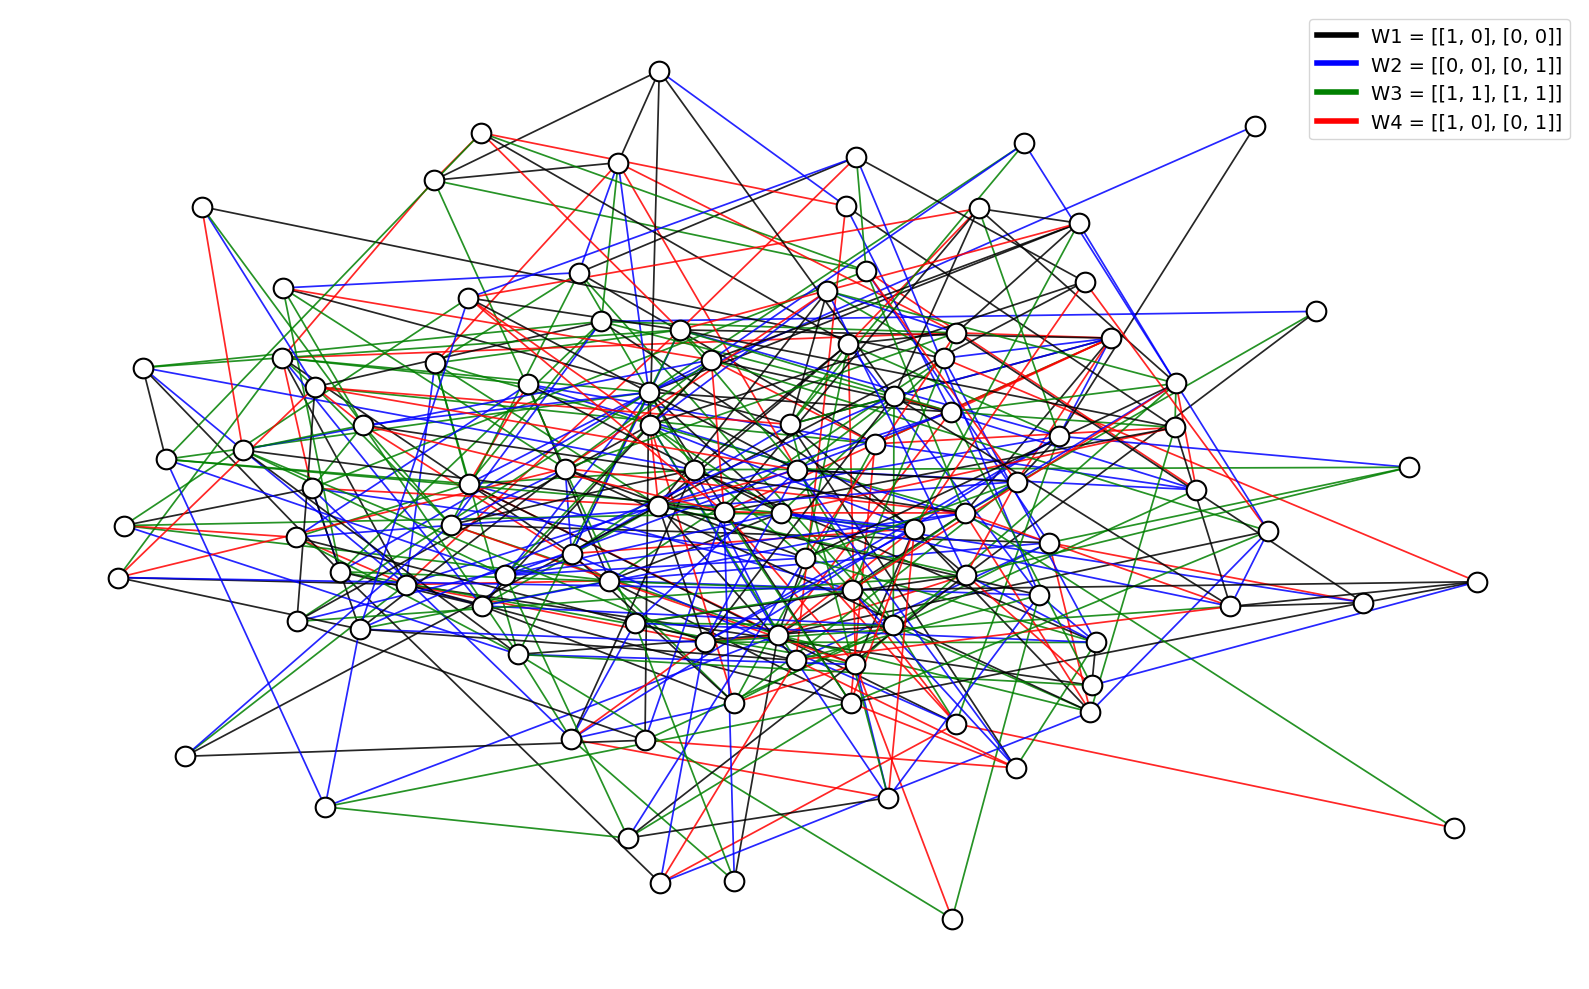

In [9]:
# ============================================================
# Example 1a: A connected matrix-weighted graph
# ============================================================

n = 100
d = 2

p = 0.08                 # Edge probability
pd_ratio = 0.2           # 20% PD
psd_ratio = 0.8          # 80% PSD

seed = 9

np.random.seed(seed)


# ============================================================
# 1. Generate a connected ordinary graph
# ============================================================

G = nx.gnp_random_graph(n, p, seed=seed)

while not nx.is_connected(G):
    seed += 1
    G = nx.gnp_random_graph(n, p, seed=seed)


print("Number of vertices:", n)
print("Number of edges:", G.number_of_edges())


# ============================================================
# 2. Define possible matrix weights
# ============================================================

# ------------------------------------------------------------
# Singular PSD matrix W1
# ------------------------------------------------------------

W1 = np.array([
    [1, 0],
    [0, 0]
], dtype=float)


# ------------------------------------------------------------
# Singular PSD matrix W2
# ------------------------------------------------------------

W2 = np.array([
    [0, 0],
    [0, 1]
], dtype=float)


# ------------------------------------------------------------
# Singular PSD matrix W3
# ------------------------------------------------------------

W3 = np.array([
    [1, 1],
    [1, 1]
], dtype=float)


# ------------------------------------------------------------
# Positive definite matrix W4
# ------------------------------------------------------------

W4 = np.array([
    [1, 0],
    [0, 1]
], dtype=float)


# ------------------------------------------------------------
# Collection of PSD matrix weights
# ------------------------------------------------------------

psd_weights = [
    W1,
    W2,
    W3
]


# ============================================================
# 3. Construct matrix-weighted adjacency matrix
# ============================================================

A = np.zeros((d * n, d * n))


edges = list(G.edges())
num_edges = len(edges)

num_PD = round(pd_ratio * num_edges)


# ------------------------------------------------------------
# Randomly select the PD edges
# ------------------------------------------------------------

PD_indices = np.random.choice(
    num_edges,
    size=num_PD,
    replace=False
)

PD_indices = set(PD_indices)


# ------------------------------------------------------------
# Counters
# ------------------------------------------------------------

num_PD_actual = 0
num_PSD_actual = 0


# ============================================================
# 4. Assign matrix weights
# ============================================================

for edge_index, (i, j) in enumerate(edges):

    # --------------------------------------------------------
    # PD edge
    # --------------------------------------------------------

    if edge_index in PD_indices:

        W = W4.copy()

        num_PD_actual += 1

        edge_type = "PD"

    # --------------------------------------------------------
    # Singular PSD edge
    # --------------------------------------------------------

    else:

        # Randomly select one of W1, W2, W3
        W = psd_weights[
            np.random.choice(len(psd_weights))
        ].copy()

        num_PSD_actual += 1

        edge_type = "PSD"


    # --------------------------------------------------------
    # Store matrix weight in NetworkX graph
    # --------------------------------------------------------

    G[i][j]["weight_matrix"] = W
    G[i][j]["type"] = edge_type


    # --------------------------------------------------------
    # Put W into A_ij
    # --------------------------------------------------------

    A[
        i*d:(i+1)*d,
        j*d:(j+1)*d
    ] = W


    # --------------------------------------------------------
    # Put W into A_ji
    # --------------------------------------------------------

    A[
        j*d:(j+1)*d,
        i*d:(i+1)*d
    ] = W


# ============================================================
# 5. Display statistics
# ============================================================

print()
print("Total edges:", num_edges)

print("PD edges:", num_PD_actual)
print("PSD edges:", num_PSD_actual)

print(
    "PD percentage:",
    100 * num_PD_actual / num_edges,
    "%"
)

print(
    "PSD percentage:",
    100 * num_PSD_actual / num_edges,
    "%"
)

print()
print("A shape:", A.shape)


# ============================================================
# 6. Verify the matrix weights
# ============================================================

PD_count = 0
PSD_count = 0


for i, j in edges:

    W = A[
        i*d:(i+1)*d,
        j*d:(j+1)*d
    ]

    eigenvalues = np.linalg.eigvalsh(W)


    # --------------------------------------------------------
    # Positive definite
    # --------------------------------------------------------

    if np.all(eigenvalues > 1e-8):

        PD_count += 1


    # --------------------------------------------------------
    # Positive semidefinite
    # --------------------------------------------------------

    elif np.all(eigenvalues >= -1e-8):

        PSD_count += 1


    # --------------------------------------------------------
    # Neither PD nor PSD
    # --------------------------------------------------------

    else:

        print("ERROR: Weight is not PSD!")


print()
print("Verified PD weights:", PD_count)
print("Verified PSD weights:", PSD_count)


# ============================================================
# 7. Identify unique matrix weights
# ============================================================

unique_weights = {}


for i, j in edges:

    W = G[i][j]["weight_matrix"]

    # Convert matrix to hashable tuple
    key = tuple(W.flatten())

    if key not in unique_weights:

        unique_weights[key] = W


print()
print(
    "Number of different matrix weights:",
    len(unique_weights)
)


# ============================================================
# 8. Assign a fixed color to each matrix weight
# ============================================================

# ------------------------------------------------------------
# W4 -> RED
# W1 -> BLACK
# W2 -> BLUE
# W3 -> GREEN
# ------------------------------------------------------------

weight_colors = {

    tuple(W1.flatten()): "black",

    tuple(W2.flatten()): "blue",

    tuple(W3.flatten()): "green",

    tuple(W4.flatten()): "red"
}


# ============================================================
# 9. Generate graph layout
# ============================================================

pos = nx.spring_layout(
    G,
    seed=12
)


# ============================================================
# 10. Create figure
# ============================================================

plt.figure(
    figsize=(16, 10)
)


# ============================================================
# 11. Draw nodes
# ============================================================

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=200,
    node_color="white",
    edgecolors="black",
    linewidths=1.5
)


# ============================================================
# 12. Draw node labels
# ============================================================

#nx.draw_networkx_labels(
#    G,
#    pos #,
    #font_size=9,
    #font_weight="bold"
#)


# ============================================================
# 13. Draw edges according to matrix weight
# ============================================================

for i, j in edges:

    W = G[i][j]["weight_matrix"]

    key = tuple(W.flatten())

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(i, j)],
        edge_color=weight_colors[key],
        width=1.25,
        alpha=0.85
    )


# ============================================================
# 14. Create legend
# ============================================================

legend_elements = []


# ------------------------------------------------------------
# Labels for the four matrix weights
# ------------------------------------------------------------

weight_labels = {
    tuple(W1.flatten()):
        "W1 = [[1, 0], [0, 0]]",

    tuple(W2.flatten()):
        "W2 = [[0, 0], [0, 1]]",

    tuple(W3.flatten()):
        "W3 = [[1, 1], [1, 1]]",

    tuple(W4.flatten()):
        "W4 = [[1, 0], [0, 1]]"
}


# ------------------------------------------------------------
# Define legend order
# ------------------------------------------------------------

legend_order = [
    tuple(W1.flatten()),
    tuple(W2.flatten()),
    tuple(W3.flatten()),
    tuple(W4.flatten())
]


# ------------------------------------------------------------
# Create legend handles
# ------------------------------------------------------------

for key in legend_order:

    legend_elements.append(
        Line2D(
            [0],
            [0],
            color=weight_colors[key],
            lw=4,
            label=weight_labels[key]
        )
    )


# ------------------------------------------------------------
# Display legend
# ------------------------------------------------------------
# from matplotlib.patches import Patch


plt.legend(
    handles=legend_elements,
    loc="best",
    fontsize=14,
    frameon=True
)



#plt.legend(
#    handles=legend_elements,
#    loc='upper right',
#    fontsize=10,
#    frameon=True
#)

# ============================================================
# 15. Figure formatting
# ============================================================

plt.axis("off")


#plt.title(
#    "Matrix-Weighted Graph",
#    fontsize=16
#)


plt.tight_layout()


# ============================================================
# 16. Show figure
# ============================================================

plt.savefig('MWG100a.png', dpi=300, bbox_inches='tight')
tikzplotlib.save(
    "MWG100a.tex",
    standalone=False
)
plt.show()


In [10]:
L = np.zeros((n*d, n*d))

for i in range(n):
    L[i*d:(i+1)*d, i*d:(i+1)*d] = np.zeros((d,d))
    for j in range(n):
        if j!=i:
            # Off-diagonal block
            L[i*d:(i+1)*d, j*d:(j+1)*d] = -A[i*d:(i+1)*d,j*d:(j+1)*d]
            L[i*d:(i+1)*d, i*d:(i+1)*d] = L[i*d:(i+1)*d, i*d:(i+1)*d] + A[i*d:(i+1)*d,j*d:(j+1)*d]
        
    # Diagonal block
    # L[i*d:(i+1)*d, i*d:(i+1)*d] = np.sum(A[i], axis=0)

rank_L = np.linalg.matrix_rank(L)

print("rank(L) =", rank_L)

rank(L) = 198


In [11]:
# ============================================================
# 6. Run generalized Warshall algorithm
# ============================================================
start = time.time()

C, k = Warshall(A, n, d)

elapsed = time.time() - start

print()
print("Warshall result:")
print("k =", k)
print("Elapsed time =", elapsed, "seconds")


Warshall result:
k = 6
Elapsed time = 1753.012928724289 seconds


In [12]:
print(C)

[[1. 0. 1. ... 0. 1. 0.]
 [0. 1. 0. ... 1. 0. 1.]
 [1. 0. 1. ... 0. 1. 0.]
 ...
 [0. 1. 0. ... 1. 0. 1.]
 [1. 0. 1. ... 0. 1. 0.]
 [0. 1. 0. ... 1. 0. 1.]]


In [13]:
print(C.shape)

(200, 200)


In [14]:
print(C[0,:])

[1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0.
 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0.
 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0.
 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0.
 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0.
 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0.
 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0.
 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0.
 1. 0. 1. 0. 1. 0. 1. 0.]


In [15]:
print(C[1,:])

[0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.
 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.
 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.
 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.
 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.
 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.
 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.
 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.
 0. 1. 0. 1. 0. 1. 0. 1.]


Number of vertices: 100
Number of edges: 274

Total edges: 274
PD edges: 22
PSD edges: 252
PD percentage: 8.02919708029197 %
PSD percentage: 91.97080291970804 %

A shape: (200, 200)

Verified PD weights: 22
Verified PSD weights: 252

Number of different matrix weights: 4


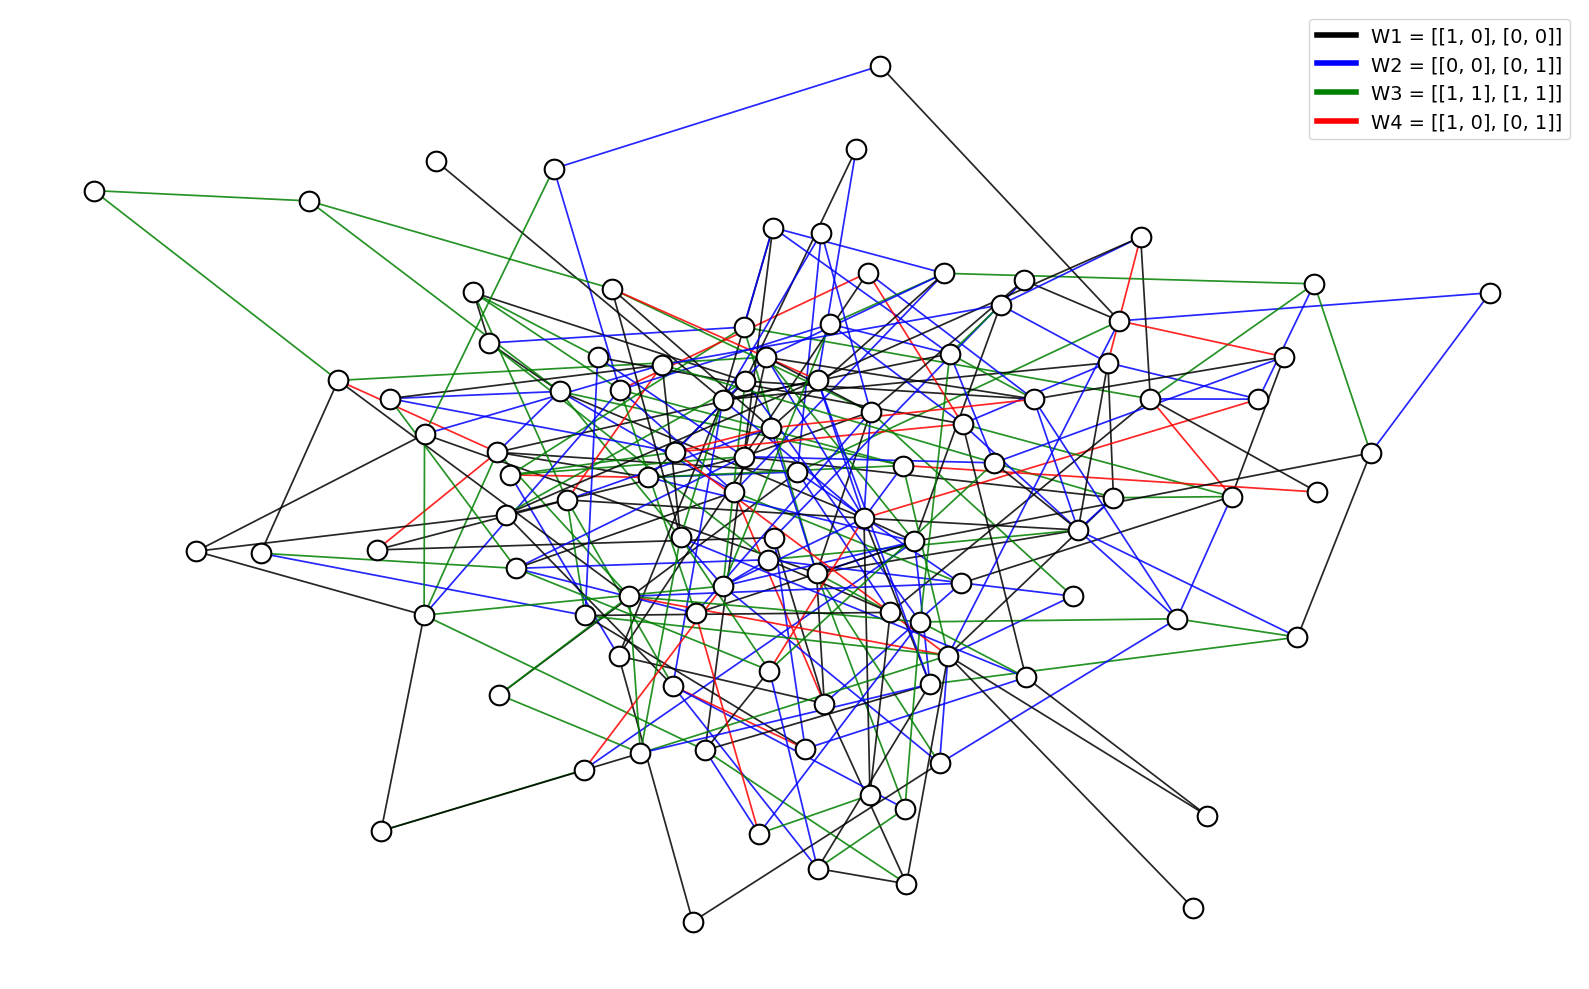

rank(L) = 189


In [17]:
# ============================================================
# Example 1b: A clustered matrix-weighted graph
# ============================================================

n = 100
d = 2

p = 0.05                 # Edge probability
pd_ratio = 0.08           # 20% PD
psd_ratio = 0.92          # 80% PSD

seed = 9

np.random.seed(seed)


# ============================================================
# 1. Generate a connected ordinary graph
# ============================================================

G = nx.gnp_random_graph(n, p, seed=seed)

while not nx.is_connected(G):
    seed += 1
    G = nx.gnp_random_graph(n, p, seed=seed)


print("Number of vertices:", n)
print("Number of edges:", G.number_of_edges())


# ============================================================
# 2. Define possible matrix weights
# ============================================================

# ------------------------------------------------------------
# Singular PSD matrix W1
# ------------------------------------------------------------

W1 = np.array([
    [1, 0],
    [0, 0]
], dtype=float)


# ------------------------------------------------------------
# Singular PSD matrix W2
# ------------------------------------------------------------

W2 = np.array([
    [0, 0],
    [0, 1]
], dtype=float)


# ------------------------------------------------------------
# Singular PSD matrix W3
# ------------------------------------------------------------

W3 = np.array([
    [1, 1],
    [1, 1]
], dtype=float)


# ------------------------------------------------------------
# Positive definite matrix W4
# ------------------------------------------------------------

W4 = np.array([
    [1, 0],
    [0, 1]
], dtype=float)


# ------------------------------------------------------------
# Collection of PSD matrix weights
# ------------------------------------------------------------

psd_weights = [
    W1,
    W2,
    W3
]


# ============================================================
# 3. Construct matrix-weighted adjacency matrix
# ============================================================

A = np.zeros((d * n, d * n))


edges = list(G.edges())
num_edges = len(edges)

num_PD = round(pd_ratio * num_edges)


# ------------------------------------------------------------
# Randomly select the PD edges
# ------------------------------------------------------------

PD_indices = np.random.choice(
    num_edges,
    size=num_PD,
    replace=False
)

PD_indices = set(PD_indices)


# ------------------------------------------------------------
# Counters
# ------------------------------------------------------------

num_PD_actual = 0
num_PSD_actual = 0


# ============================================================
# 4. Assign matrix weights
# ============================================================

for edge_index, (i, j) in enumerate(edges):

    # --------------------------------------------------------
    # PD edge
    # --------------------------------------------------------

    if edge_index in PD_indices:

        W = W4.copy()

        num_PD_actual += 1

        edge_type = "PD"

    # --------------------------------------------------------
    # Singular PSD edge
    # --------------------------------------------------------

    else:

        # Randomly select one of W1, W2, W3
        W = psd_weights[
            np.random.choice(len(psd_weights))
        ].copy()

        num_PSD_actual += 1

        edge_type = "PSD"


    # --------------------------------------------------------
    # Store matrix weight in NetworkX graph
    # --------------------------------------------------------

    G[i][j]["weight_matrix"] = W
    G[i][j]["type"] = edge_type


    # --------------------------------------------------------
    # Put W into A_ij
    # --------------------------------------------------------

    A[
        i*d:(i+1)*d,
        j*d:(j+1)*d
    ] = W


    # --------------------------------------------------------
    # Put W into A_ji
    # --------------------------------------------------------

    A[
        j*d:(j+1)*d,
        i*d:(i+1)*d
    ] = W


# ============================================================
# 5. Display statistics
# ============================================================

print()
print("Total edges:", num_edges)

print("PD edges:", num_PD_actual)
print("PSD edges:", num_PSD_actual)

print(
    "PD percentage:",
    100 * num_PD_actual / num_edges,
    "%"
)

print(
    "PSD percentage:",
    100 * num_PSD_actual / num_edges,
    "%"
)

print()
print("A shape:", A.shape)


# ============================================================
# 6. Verify the matrix weights
# ============================================================

PD_count = 0
PSD_count = 0


for i, j in edges:

    W = A[
        i*d:(i+1)*d,
        j*d:(j+1)*d
    ]

    eigenvalues = np.linalg.eigvalsh(W)


    # --------------------------------------------------------
    # Positive definite
    # --------------------------------------------------------

    if np.all(eigenvalues > 1e-8):

        PD_count += 1


    # --------------------------------------------------------
    # Positive semidefinite
    # --------------------------------------------------------

    elif np.all(eigenvalues >= -1e-8):

        PSD_count += 1


    # --------------------------------------------------------
    # Neither PD nor PSD
    # --------------------------------------------------------

    else:

        print("ERROR: Weight is not PSD!")


print()
print("Verified PD weights:", PD_count)
print("Verified PSD weights:", PSD_count)


# ============================================================
# 7. Identify unique matrix weights
# ============================================================

unique_weights = {}


for i, j in edges:

    W = G[i][j]["weight_matrix"]

    # Convert matrix to hashable tuple
    key = tuple(W.flatten())

    if key not in unique_weights:

        unique_weights[key] = W


print()
print(
    "Number of different matrix weights:",
    len(unique_weights)
)


# ============================================================
# 8. Assign a fixed color to each matrix weight
# ============================================================

# ------------------------------------------------------------
# W4 -> RED
# W1 -> BLACK
# W2 -> BLUE
# W3 -> GREEN
# ------------------------------------------------------------

weight_colors = {

    tuple(W1.flatten()): "black",

    tuple(W2.flatten()): "blue",

    tuple(W3.flatten()): "green",

    tuple(W4.flatten()): "red"
}


# ============================================================
# 9. Generate graph layout
# ============================================================

pos = nx.spring_layout(
    G,
    seed=12
)


# ============================================================
# 10. Create figure
# ============================================================

plt.figure(
    figsize=(16, 10)
)


# ============================================================
# 11. Draw nodes
# ============================================================

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=200,
    node_color="white",
    edgecolors="black",
    linewidths=1.5
)


# ============================================================
# 12. Draw node labels
# ============================================================

#nx.draw_networkx_labels(
#    G,
#    pos #,
    #font_size=9,
    #font_weight="bold"
#)


# ============================================================
# 13. Draw edges according to matrix weight
# ============================================================

for i, j in edges:

    W = G[i][j]["weight_matrix"]

    key = tuple(W.flatten())

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(i, j)],
        edge_color=weight_colors[key],
        width=1.25,
        alpha=0.85
    )


# ============================================================
# 14. Create legend
# ============================================================

legend_elements = []


# ------------------------------------------------------------
# Labels for the four matrix weights
# ------------------------------------------------------------

weight_labels = {
    tuple(W1.flatten()):
        "W1 = [[1, 0], [0, 0]]",

    tuple(W2.flatten()):
        "W2 = [[0, 0], [0, 1]]",

    tuple(W3.flatten()):
        "W3 = [[1, 1], [1, 1]]",

    tuple(W4.flatten()):
        "W4 = [[1, 0], [0, 1]]"
}


# ------------------------------------------------------------
# Define legend order
# ------------------------------------------------------------

legend_order = [
    tuple(W1.flatten()),
    tuple(W2.flatten()),
    tuple(W3.flatten()),
    tuple(W4.flatten())
]


# ------------------------------------------------------------
# Create legend handles
# ------------------------------------------------------------

for key in legend_order:

    legend_elements.append(
        Line2D(
            [0],
            [0],
            color=weight_colors[key],
            lw=4,
            label=weight_labels[key]
        )
    )


# ------------------------------------------------------------
# Display legend
# ------------------------------------------------------------
# from matplotlib.patches import Patch


plt.legend(
    handles=legend_elements,
    loc="best",
    fontsize=14,
    frameon=True
)



#plt.legend(
#    handles=legend_elements,
#    loc='upper right',
#    fontsize=10,
#    frameon=True
#)

# ============================================================
# 15. Figure formatting
# ============================================================

plt.axis("off")


#plt.title(
#    "Matrix-Weighted Graph",
#    fontsize=16
#)


plt.tight_layout()


# ============================================================
# 16. Show figure
# ============================================================

plt.savefig('MWG100b.png', dpi=300, bbox_inches='tight')
tikzplotlib.save(
    "MWG100b.tex",
    standalone=False
)
plt.show()

L = np.zeros((n*d, n*d))

for i in range(n):
    L[i*d:(i+1)*d, i*d:(i+1)*d] = np.zeros((d,d))
    for j in range(n):
        if j!=i:
            # Off-diagonal block
            L[i*d:(i+1)*d, j*d:(j+1)*d] = -A[i*d:(i+1)*d,j*d:(j+1)*d]
            L[i*d:(i+1)*d, i*d:(i+1)*d] = L[i*d:(i+1)*d, i*d:(i+1)*d] + A[i*d:(i+1)*d,j*d:(j+1)*d]
        
    # Diagonal block
    # L[i*d:(i+1)*d, i*d:(i+1)*d] = np.sum(A[i], axis=0)

rank_L = np.linalg.matrix_rank(L)

print("rank(L) =", rank_L)

In [18]:
# ============================================================
# Run generalized Warshall algorithm with early terminal = 7
# ============================================================
start = time.time()

C, k = Warshall_ET(A, n, d, 7)

elapsed = time.time() - start

print()
print("Warshall result:")
print("k =", k)
print("Elapsed time =", elapsed, "seconds")


Warshall result:
k = 7
Elapsed time = 2490.0322251319885 seconds


In [31]:
# Find a partition into clusters of the graph from matrix C
def clusterFromC(C, n, d, tol = 1e-6):
    Cluster = {}
    L = np.arange(1, n+1)
    
    for i in range(n):
        if L[i]>=i+1:    # if i+1 does not belong to any cluster
            clt = [i+1]  # create a new cluster containing i+1
            for j in range(i+1,n,1): # find vertices j+1 that i+1 can fully connected to after k=ET
                if L[j]>=j+1 and np.sum(np.abs(C[i*d:(i+1)*d, j*d:(j+1)*d]-np.eye(d))) < tol:
                    clt = np.append(clt, j+1) # include these vertices to the cluster containing i+1
                    L[j] = i+1                # mark that j+1 belongs to cluster i+1
            Cluster[i+1] = clt                # Add cluster containing i+1 to output
        else:            # if i+1 belongs to a cluster L[i]<i+1
            clt = Cluster[L[i]].copy()        # Continue to modify cluster containing L[i]
            for j in range(i+1,n,1): # find more vertices j+1 that i+1 can fully connected to after k=ET
                if L[j]>=j+1 and np.sum(np.abs(C[i*d:(i+1)*d, j*d:(j+1)*d]-np.eye(d))) < tol:
                    clt = np.append(clt, j+1) 
                    L[j] = L[i]              # mark that j+1 belongs to cluster L[i]
            Cluster[L[i]] = clt              # Modify cluster containing L[i] in the output
    
    return Cluster

In [33]:
Cluster = clusterFromC(C, n, d)

for key, value in Cluster.items():
    print(key, ":", value)
# print(Cluster)

1 : [  1   2   3   4   5   6   8   9  10  11  12  13  14  15  16  17  18  19
  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37
  38  39  40  41  42  43  44  45  47  48  49  51  52  53  54  55  56  57
  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76
  77  78  79  80  82  83  84  85  87  88  90  92  93  94  95  97  98  99
 100]
7 : [7]
46 : [46]
50 : [50]
58 : [58]
81 : [81]
86 : [86]
89 : [89]
91 : [91]
96 : [96]
